In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sufya6/e-commerce-customer-churn-prediction/E-Commerce_Customer_Churn.csv
/kaggle/input/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset/ecommerce_customer_churn_dataset.csv
/kaggle/input/datasets/suryaprabha19/e-commerce/ecommerce_customer_data.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset/ecommerce_customer_churn_dataset.csv')
df.head(3)

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [4]:
df.isnull().sum()
# df.duplicated().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

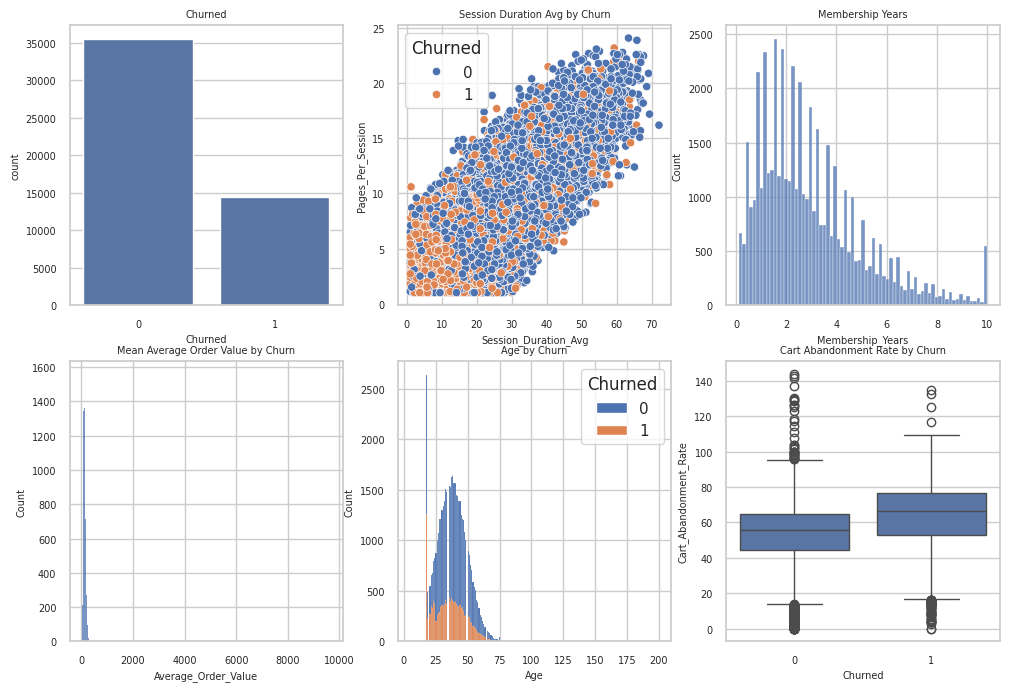

In [6]:
sns.set_theme(style="whitegrid",
    rc={ "axes.titlesize":7,
        "axes.labelsize":7,
        "xtick.labelsize":7,
        "ytick.labelsize":7,
        "font.size":7
    }
)

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
sns.countplot(x="Churned",data=df)
plt.title("Churned")

plt.subplot(2, 3, 2)
sns.scatterplot(data=df,x="Session_Duration_Avg",y="Pages_Per_Session",hue="Churned")
plt.title("Session Duration Avg by Churn")

plt.subplot(2,3,3)
sns.histplot(df["Membership_Years"])
plt.title("Membership Years")

plt.subplot(2,3,4)
sns.histplot(df["Average_Order_Value"])
plt.title("Mean Average Order Value by Churn")

plt.subplot(2,3,5)
sns.histplot(data=df,x="Age",hue="Churned",multiple="stack",alpha=1)
plt.title("Age by Churn")

plt.subplot(2,3,6)
sns.boxplot(data=df, x="Churned", y="Cart_Abandonment_Rate")
plt.title("Cart Abandonment Rate by Churn")

plt.show()

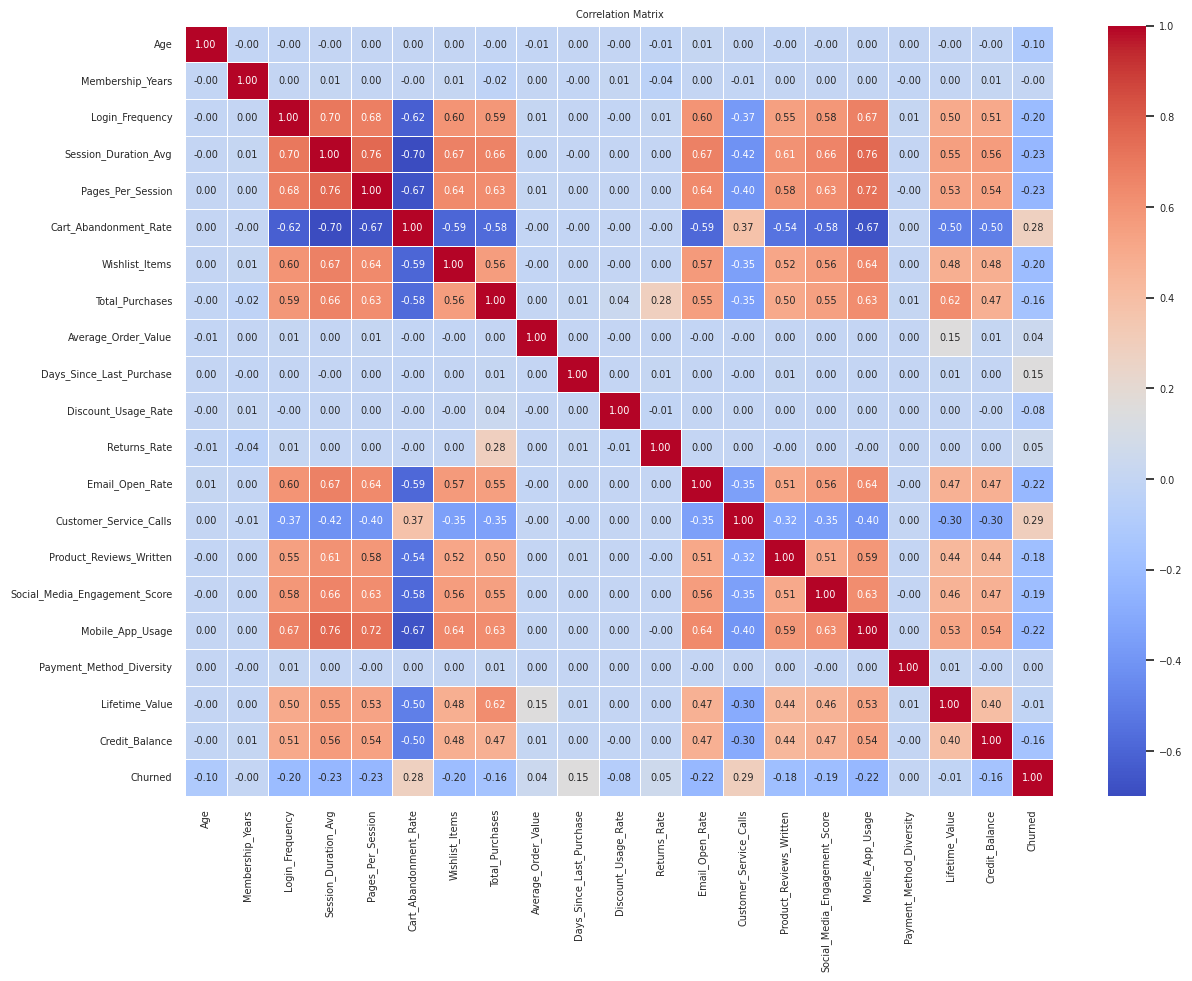

In [7]:
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",     
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

EDA Conclusion
Customer churn is mainly associated with low user engagement and inactivity. Users who log in less frequently, view fewer pages per session, and spend less time on the platform are more likely to churn. Additionally, higher cart abandonment rates and longer periods since the last purchase increase the likelihood of churn.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_curve

In [9]:
df = df.drop(columns=["City"])
df = pd.get_dummies(df, drop_first=True)

In [10]:
X = df.drop("Churned", axis=1)
y = df["Churned"]
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Prediction

In [12]:
results = []

def evaluate_model(name, y_test, y_pred):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_model("Logistic Regression", y_test, y_pred_lr)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model("Random Forest", y_test, y_pred_rf)

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)


results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.7773,0.684241,0.416028,0.517443
1,Random Forest,0.9174,0.925833,0.774216,0.843264
2,Gradient Boosting,0.9201,0.934901,0.775610,0.847839


Gradient Boosting achieved the highest ROC-AUC score (0.92), followed closely by Random Forest (0.92), while Logistic Regression showed lower performance (0.77).

In [43]:
accuracy = accuracy_score(y_test, y_pred_lr) * 100
print(f"Accuracy: {accuracy:.2f}%")

error_rate = (1 - accuracy_score(y_test, y_pred_lr)) * 100
print(f"Ошибка модели: {error_rate:.2f}%")

Accuracy: 77.73%
Ошибка модели: 22.27%


In [47]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lr
})

print(comparison.head(20))

       Actual  Predicted
33553       0          0
9427        0          0
199         1          1
12447       1          0
39489       0          0
42724       0          0
10822       1          1
49498       0          0
4144        0          0
36958       0          0
43106       1          1
38695       0          0
6188        0          0
1414        0          0
18471       1          0
29282       0          0
15177       0          0
34304       0          0
12609       0          0
12144       0          0


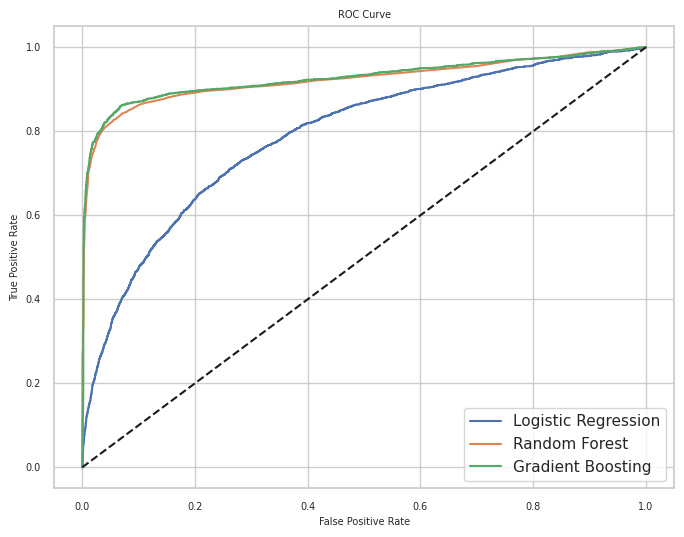

In [13]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

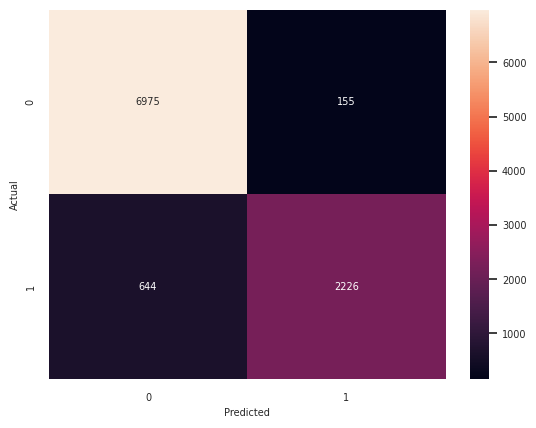

In [60]:
cm = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Feature Importance

In [15]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10)

Lifetime_Value              0.124606
Customer_Service_Calls      0.117762
Cart_Abandonment_Rate       0.095835
Age                         0.069340
Discount_Usage_Rate         0.060702
Days_Since_Last_Purchase    0.057511
Total_Purchases             0.051887
Average_Order_Value         0.049437
Email_Open_Rate             0.045278
Session_Duration_Avg        0.038886
dtype: float64

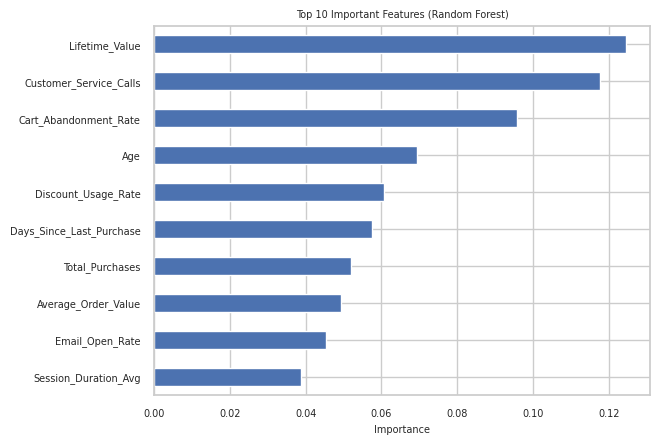

In [16]:
importance.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance")
plt.show()

Feature importance analysis revealed that customer value and engagement metrics are the strongest predictors of churn.
The most influential features include:
Lifetime Value,
Customer Service Calls,
Cart Abandonment Rate,
Discount Usage Rate,
Days Since Last Purchase,
These results indicate that low engagement, frequent support interactions, and purchase friction are strong signals of potential churn.

**Churn Probability Segmentation**

In [17]:
# churn_prob = gb.predict_proba(X_test)[:,1]
churn_prob = gb.predict_proba(X_test)[:,1]

In [19]:
churn_prob = gb.predict_proba(X_test)[:,1]

churn_df = pd.DataFrame(X_test, columns=X.columns)

churn_df["Churn_Probability"] = churn_prob
churn_df["Actual_Churn"] = y_test.values

Customer segmentation by risk

In [21]:
def churn_segment(p):
    if p < 0.3:
        return "Low Risk"
    elif p <0.6:
        return "Medium Risk"
    else:
        return "High Risk"
churn_df["Risk_Segment"] = churn_df["Churn_Probability"].apply(churn_segment)
churn_df["Risk_Segment"].value_counts()

Risk_Segment
Low Risk       7071
High Risk      2209
Medium Risk     720
Name: count, dtype: int64

In [22]:
churn_df.groupby("Risk_Segment")["Churn_Probability"].mean()

Risk_Segment
High Risk      0.893121
Low Risk       0.080592
Medium Risk    0.430784
Name: Churn_Probability, dtype: float64